<a href="https://colab.research.google.com/github/jiki007/OS_project/blob/main/SmartHome.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 🏠 Scenario 2: Smart Home Sensor Automation System

### What is this scenario?
This scenario simulates a smart home IoT (Internet of Things) environment
with 5 different sensors that continuously generate real-time data. An
automation engine monitors the sensor readings and automatically triggers
responses when values exceed safe thresholds — just like a real smart home system.

### Why is it relevant to OS?
This scenario demonstrates event-driven automation and real-time process
monitoring — two key concepts in operating systems. Just like how an OS
monitors system resources (CPU, memory) and responds when thresholds are
exceeded, our smart home system monitors environmental sensors and responds
automatically. This mirrors how Ubuntu handles interrupts and automated responses.

### How it works?
1. 5 sensors are configured with normal ranges and alert thresholds
2. Every 2 seconds, all sensors generate new random readings
3. Automation engine checks each reading against its threshold
4. If a threshold is crossed, an automated action is triggered and logged
5. After 30 seconds, charts and statistics are generated

### Sensors & Thresholds
| Sensor      | Unit | Normal Range  | High Alert Action      | Low Alert Action     |
|-------------|------|---------------|------------------------|----------------------|
| Temperature | °C   | 18°C - 30°C   | Fan activated          | Heater activated     |
| Humidity    | %    | 30% - 70%     | Dehumidifier activated | Humidifier activated |
| Motion      | 0/1  | 0 or 1        | -                      | -                    |
| CO2         | ppm  | 300 - 1000    | Windows opened         | -                    |
| Light       | lux  | 100 - 800     | Blinds closed          | Lights turned on     |

### Ubuntu Concepts Used
- Real-time monitoring and event-driven responses
- Process scheduling with `time.sleep()`
- Data logging and visualization

In [ ]:
!pip install matplotlib numpy

import random
import datetime
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import defaultdict

In [ ]:
# Sensor configuration
sensors = {
    "Temperature": {
        "unit": "°C",
        "min": 18, "max": 40,
        "normal": (18, 30),
        "alert_high": 30,
        "alert_low": 18,
    },
    "Humidity": {
        "unit": "%",
        "min": 20, "max": 90,
        "normal": (30, 70),
        "alert_high": 70,
        "alert_low": 30,
    },
    "Motion": {
        "unit": "detected",
        "min": 0, "max": 1,
        "normal": (0, 1),
        "alert_high": None,
        "alert_low": None,
    },
    "CO2": {
        "unit": "ppm",
        "min": 300, "max": 2000,
        "normal": (300, 1000),
        "alert_high": 1000,
        "alert_low": None,
    },
    "Light": {
        "unit": "lux",
        "min": 0, "max": 1000,
        "normal": (100, 800),
        "alert_high": 800,
        "alert_low": 100,
    },
}

# Automation rules
automation_rules = {
    "Temperature": {
        "high": "🌀 Fan activated!",
        "low": "🔥 Heater activated!",
    },
    "Humidity": {
        "high": "💨 Dehumidifier activated!",
        "low": "💧 Humidifier activated!",
    },
    "CO2": {
        "high": "🪟 Windows opened for ventilation!",
    },
    "Light": {
        "high": "🕶️ Blinds closed!",
        "low": "💡 Lights turned on!",
    },
}

print("✅ Sensors and automation rules configured!")
print(f"   Sensors  : {list(sensors.keys())}")
print(f"   Rules    : {list(automation_rules.keys())}")

✅ Sensors and automation rules configured!
   Sensors  : ['Temperature', 'Humidity', 'Motion', 'CO2', 'Light']
   Rules    : ['Temperature', 'Humidity', 'CO2', 'Light']


In [ ]:
sensor_data = defaultdict(list)
timestamps = []
event_log = []

def generate_sensor_reading(sensor_name):
    config = sensors[sensor_name]
    if sensor_name == "Motion":
        return random.choice([0, 0, 0, 1])  # mostly no motion
    return round(random.uniform(config["min"], config["max"]), 2)

def check_automation(sensor_name, value):
    config = sensors[sensor_name]
    rules = automation_rules.get(sensor_name, {})
    actions = []

    if config["alert_high"] and value > config["alert_high"]:
        action = rules.get("high", f"⚠️ High {sensor_name} alert!")
        actions.append(("HIGH", action))

    if config["alert_low"] and value < config["alert_low"]:
        action = rules.get("low", f"⚠️ Low {sensor_name} alert!")
        actions.append(("LOW", action))

    return actions

def simulate_sensors(duration=30, interval=2):
    print("📡 Smart Home Sensor System Started")
    print(f"   Running for {duration} seconds...\n")
    print("-" * 60)

    start = time.time()
    reading_count = 0

    while time.time() - start < duration:
        now = datetime.datetime.now()
        timestamps.append(now)
        reading_count += 1

        print(f"[{now.strftime('%H:%M:%S')}] Reading #{reading_count}")

        for sensor_name in sensors:
            value = generate_sensor_reading(sensor_name)
            sensor_data[sensor_name].append(value)
            unit = sensors[sensor_name]["unit"]
            print(f"  {sensor_name:<15}: {value} {unit}")

            # Check automation rules
            actions = check_automation(sensor_name, value)
            for level, action in actions:
                print(f"    → {action}")
                event_log.append({
                    "time": now.strftime("%H:%M:%S"),
                    "sensor": sensor_name,
                    "value": value,
                    "level": level,
                    "action": action
                })

        print()
        time.sleep(interval)

    print("-" * 60)
    print(f"✅ Simulation complete! Total readings: {reading_count}")

simulate_sensors(duration=30, interval=2)

📡 Smart Home Sensor System Started
   Running for 30 seconds...

------------------------------------------------------------
[00:50:51] Reading #1
  Temperature    : 39.35 °C
    → 🌀 Fan activated!
  Humidity       : 29.46 %
    → 💧 Humidifier activated!
  Motion         : 0 detected
  CO2            : 1732.22 ppm
    → 🪟 Windows opened for ventilation!
  Light          : 401.89 lux

[00:50:53] Reading #2
  Temperature    : 35.94 °C
    → 🌀 Fan activated!
  Humidity       : 42.31 %
  Motion         : 0 detected
  CO2            : 570.95 ppm
  Light          : 48.78 lux
    → 💡 Lights turned on!

[00:50:55] Reading #3
  Temperature    : 28.13 °C
  Humidity       : 57.49 %
  Motion         : 0 detected
  CO2            : 736.85 ppm
  Light          : 599.47 lux

[00:50:57] Reading #4
  Temperature    : 19.47 °C
  Humidity       : 32.64 %
  Motion         : 0 detected
  CO2            : 1883.9 ppm
    → 🪟 Windows opened for ventilation!
  Light          : 148.86 lux

[00:50:59] Reading #

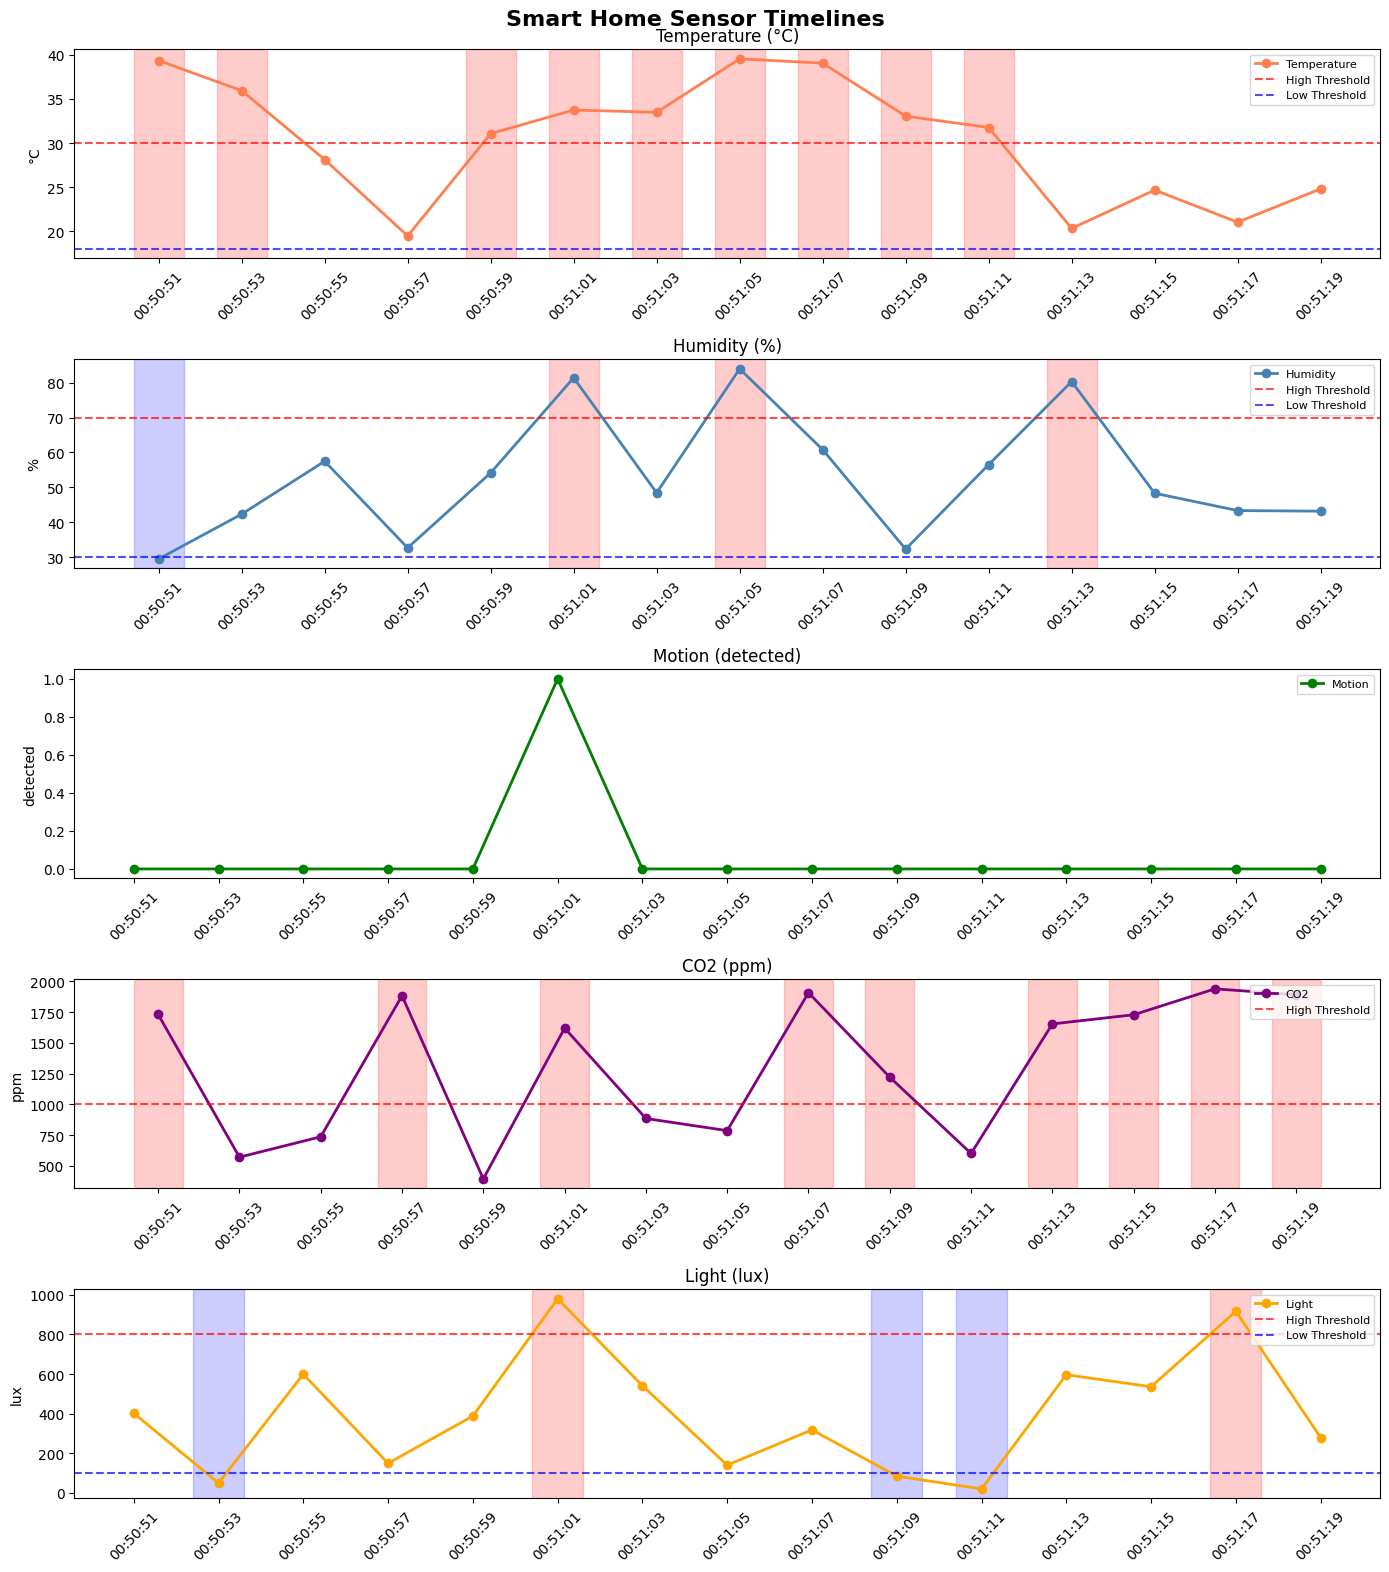

In [ ]:
def visualize_sensor_timelines():
    fig, axes = plt.subplots(len(sensors), 1, figsize=(14, 16))
    time_labels = [t.strftime("%H:%M:%S") for t in timestamps]

    colors = ["coral", "steelblue", "green", "purple", "orange"]

    for i, (sensor_name, values) in enumerate(sensor_data.items()):
        ax = axes[i]
        config = sensors[sensor_name]
        ax.plot(time_labels, values, color=colors[i], marker='o', linewidth=2, label=sensor_name)

        # Draw threshold lines
        if config["alert_high"]:
            ax.axhline(y=config["alert_high"], color='red', linestyle='--', alpha=0.7, label='High Threshold')
        if config["alert_low"]:
            ax.axhline(y=config["alert_low"], color='blue', linestyle='--', alpha=0.7, label='Low Threshold')

        ax.set_title(f"{sensor_name} ({config['unit']})", fontsize=12)
        ax.set_ylabel(config["unit"])
        ax.legend(loc="upper right", fontsize=8)
        ax.tick_params(axis='x', rotation=45)

        # Highlight alert zones
        for j, val in enumerate(values):
            if config["alert_high"] and val > config["alert_high"]:
                ax.axvspan(j - 0.3, j + 0.3, alpha=0.2, color='red')
            elif config["alert_low"] and val < config["alert_low"]:
                ax.axvspan(j - 0.3, j + 0.3, alpha=0.2, color='blue')

    plt.suptitle("Smart Home Sensor Timelines", fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

visualize_sensor_timelines()

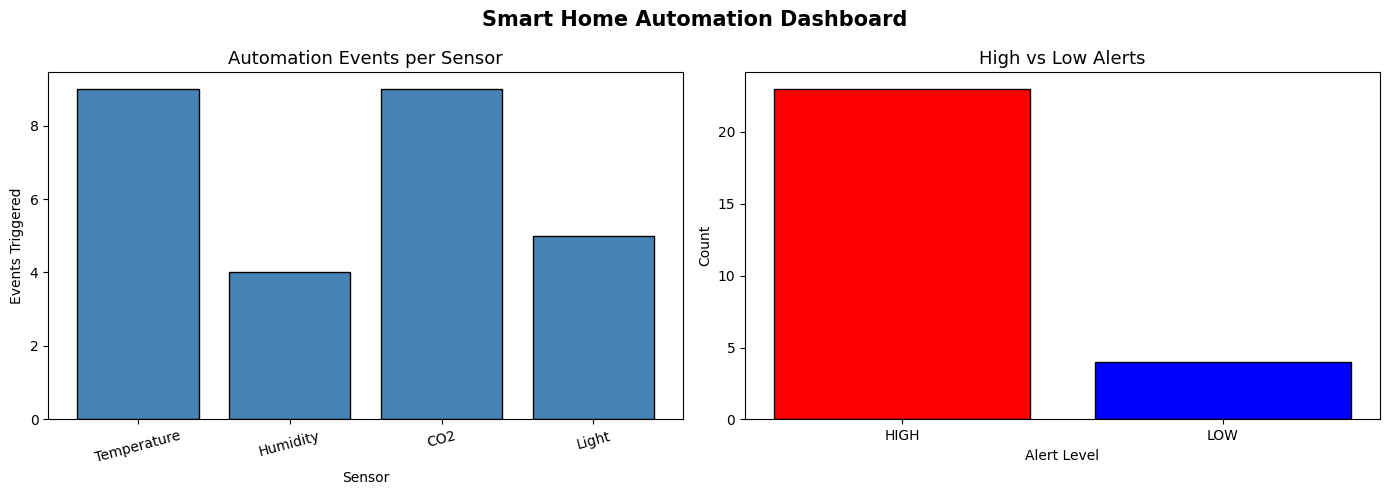

In [ ]:
def visualize_events():
    if not event_log:
        print("No automation events triggered.")
        return

    # Event count per sensor
    from collections import Counter
    sensor_events = Counter(e["sensor"] for e in event_log)
    level_events = Counter(e["level"] for e in event_log)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Events per sensor
    axes[0].bar(sensor_events.keys(), sensor_events.values(),
                color="steelblue", edgecolor="black")
    axes[0].set_title("Automation Events per Sensor", fontsize=13)
    axes[0].set_xlabel("Sensor")
    axes[0].set_ylabel("Events Triggered")
    axes[0].tick_params(axis='x', rotation=15)

    # High vs Low alerts
    axes[1].bar(level_events.keys(), level_events.values(),
                color=["red", "blue"], edgecolor="black")
    axes[1].set_title("High vs Low Alerts", fontsize=13)
    axes[1].set_xlabel("Alert Level")
    axes[1].set_ylabel("Count")

    plt.suptitle("Smart Home Automation Dashboard", fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.show()

visualize_events()

In [ ]:
def print_statistics():
    print(f"\n{'Sensor':<15} {'Min':<10} {'Max':<10} {'Average':<10} {'Alerts':<10}")
    print("-" * 55)

    for sensor_name, values in sensor_data.items():
        unit = sensors[sensor_name]["unit"]
        alerts = sum(1 for e in event_log if e["sensor"] == sensor_name)
        print(f"{sensor_name:<15} "
              f"{min(values):<10} "
              f"{max(values):<10} "
              f"{round(sum(values)/len(values), 2):<10} "
              f"{alerts:<10}")

print_statistics()


Sensor          Min        Max        Average    Alerts    
-------------------------------------------------------
Temperature     19.47      39.54      30.36      9         
Humidity        29.46      84.0       52.98      4         
Motion          0          1          0.07       0         
CO2             393.76     1940.13    1303.88    9         
Light           19.27      979.96     399.77     5         


In [ ]:
if event_log:
    print(f"\n{'Time':<12} {'Sensor':<15} {'Value':<10} {'Level':<8} Action")
    print("-" * 75)
    for e in event_log:
        print(f"{e['time']:<12} {e['sensor']:<15} {e['value']:<10} {e['level']:<8} {e['action']}")
else:
    print("No automation events were triggered during this session.")


Time         Sensor          Value      Level    Action
---------------------------------------------------------------------------
00:50:51     Temperature     39.35      HIGH     🌀 Fan activated!
00:50:51     Humidity        29.46      LOW      💧 Humidifier activated!
00:50:51     CO2             1732.22    HIGH     🪟 Windows opened for ventilation!
00:50:53     Temperature     35.94      HIGH     🌀 Fan activated!
00:50:53     Light           48.78      LOW      💡 Lights turned on!
00:50:57     CO2             1883.9     HIGH     🪟 Windows opened for ventilation!
00:50:59     Temperature     31.07      HIGH     🌀 Fan activated!
00:51:01     Temperature     33.74      HIGH     🌀 Fan activated!
00:51:01     Humidity        81.44      HIGH     💨 Dehumidifier activated!
00:51:01     CO2             1620.81    HIGH     🪟 Windows opened for ventilation!
00:51:01     Light           979.96     HIGH     🕶️ Blinds closed!
00:51:03     Temperature     33.48      HIGH     🌀 Fan activated!
00:5